In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
from datetime import datetime

import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding
from tqdm.auto import tqdm

In [2]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1


device(type='cuda')

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
ann = pd.read_csv("../data/processed/mhs_main_experiment_annotations_with_split.csv")

print("Annotation rows:", ann.shape)
print("Unique comments:", ann["comment_id"].nunique())
print(ann["split"].value_counts())

Annotation rows: (49433, 53)
Unique comments: 19761
split
train         34413
test           7713
validation     7307
Name: count, dtype: int64


In [5]:
task_specs = {
    "hatespeech": [0, 1, 2],
    "humiliate": [0, 1, 2, 3, 4],
    "insult": [0, 1, 2, 3, 4],
}

task_names = list(task_specs.keys())
task_names

['hatespeech', 'humiliate', 'insult']

In [6]:
def make_distribution(group, label_col, label_values):
    counts = group[label_col].value_counts(normalize=True)
    return pd.Series({
        f"{label_col}_{label}_prob": counts.get(label, 0.0)
        for label in label_values
    })

In [7]:
metadata = (
    ann.groupby("comment_id")
    .agg(
        text_clean=("text_clean", "first"),
        split=("split", "first"),
        target_type=("target_type", "first"),
        is_women_targeted=("is_women_targeted", "max"),
        is_immigrant_targeted=("is_immigrant_targeted", "max"),
        annotation_count=("annotator_id", "count"),
        unique_annotators=("annotator_id", "nunique")
    )
    .reset_index()
)

comment_df = metadata.copy()

for task, label_values in task_specs.items():
    dist = (
        ann.groupby("comment_id")
        .apply(lambda g, task=task, label_values=label_values: make_distribution(g, task, label_values))
        .reset_index()
    )
    comment_df = comment_df.merge(dist, on="comment_id", how="left")

print("All comment-level rows:", comment_df.shape)
comment_df.head()

All comment-level rows: (19761, 21)


,comment_id,text_clean,split,target_type,is_women_targeted,is_immigrant_targeted,annotation_count,unique_annotators,hatespeech_0_prob,hatespeech_1_prob,...,humiliate_0_prob,humiliate_1_prob,humiliate_2_prob,humiliate_3_prob,humiliate_4_prob,insult_0_prob,insult_1_prob,insult_2_prob,insult_3_prob,insult_4_prob
0,6,First off you look cool as fuck! Anyway if we ...,train,women_only,1,0,2,2,1.000000,0.0,...,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.0,0.500000,0.500000
1,7,\*points to posters asking for palestinian rig...,test,immigrant_only,0,1,2,2,0.500000,0.0,...,0.5,0.000000,0.5,0.000000,0.000000,0.5,0.0,0.0,0.500000,0.000000
2,10,"They'll come back in your plan, also. Plus we ...",train,immigrant_only,0,1,3,3,0.333333,0.0,...,0.0,0.333333,0.0,0.333333,0.333333,0.0,0.0,0.0,0.666667,0.333333
3,11,"eat my fuck, bitch",validation,women_only,1,0,2,2,0.000000,0.5,...,0.0,0.500000,0.0,0.000000,0.500000,0.0,0.0,0.0,1.000000,0.000000
4,12,She ugly anyways,train,women_only,1,0,2,2,0.500000,0.0,...,0.0,0.000000,0.5,0.000000,0.500000,0.0,0.0,0.0,0.500000,0.500000


In [8]:
# Preserve split, then filter reliable subset, then recount splits to check reliability distribution across splits
MIN_ANNOTATIONS = 3

full_split_counts = (
    comment_df.groupby("split")
    .agg(
        comments=("comment_id", "count"),
        mean_annotation_count=("annotation_count", "mean")
    )
    .reset_index()
)

reliable_df = comment_df[comment_df["annotation_count"] >= MIN_ANNOTATIONS].copy()

reliable_split_counts = (
    reliable_df.groupby("split")
    .agg(
        comments=("comment_id", "count"),
        mean_annotation_count=("annotation_count", "mean")
    )
    .reset_index()
)

print("Full split counts:")
display(full_split_counts)

print("Reliable subset split counts:")
display(reliable_split_counts)

print("Reliable subset total:", len(reliable_df))
print("Percent kept:", round(len(reliable_df) / len(comment_df) * 100, 2))

Full split counts:


,split,comments,mean_annotation_count
0,test,2965,2.601349
1,train,13832,2.487927
2,validation,2964,2.465250


Reliable subset split counts:


,split,comments,mean_annotation_count
0,test,705,6.463830
1,train,3252,6.041820
2,validation,687,5.991266


Reliable subset total: 4644
Percent kept: 23.5


In [9]:
#check that soft-label probabilities sum to 1 for each task
for task, labels in task_specs.items():
    cols = [f"{task}_{label}_prob" for label in labels]
    sums = reliable_df[cols].sum(axis=1)
    print(task, "min:", sums.min(), "max:", sums.max(), "mean:", sums.mean())

hatespeech min: 1.0 max: 1.0 mean: 1.0
humiliate min: 0.9999999999999998 max: 1.0 mean: 1.0
insult min: 0.9999999999999999 max: 1.0 mean: 1.0


In [14]:
train_df = reliable_df[reliable_df["split"] == "train"].copy()
val_df = reliable_df[reliable_df["split"] == "validation"].copy()
test_df = reliable_df[reliable_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (3252, 21)
Validation: (687, 21)
Test: (705, 21)


In [15]:
def entropy_np(probs):
    probs = np.array(probs)
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return -np.sum(probs * np.log2(probs))

entropy_rows = []

for task, labels in task_specs.items():
    cols = [f"{task}_{label}_prob" for label in labels]

    for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        entropies = split_df[cols].apply(lambda row: entropy_np(row.values), axis=1)

        entropy_rows.append({
            "task": task,
            "split": split_name,
            "comments": len(split_df),
            "mean_entropy": entropies.mean(),
            "median_entropy": entropies.median(),
            "zero_entropy_percent": round((entropies == 0).mean() * 100, 2),
            "nonzero_entropy_percent": round((entropies > 0).mean() * 100, 2)
        })

entropy_subset_summary = pd.DataFrame(entropy_rows)
entropy_subset_summary

,task,split,comments,mean_entropy,median_entropy,zero_entropy_percent,nonzero_entropy_percent
0,hatespeech,train,3252,0.499966,0.344760,49.63,50.37
1,hatespeech,validation,687,0.504006,0.508324,49.49,50.51
2,hatespeech,test,705,0.526824,0.811278,47.94,52.06
3,humiliate,train,3252,0.983703,0.918296,13.19,86.81
4,humiliate,validation,687,0.943809,0.918296,16.45,83.55
5,humiliate,test,705,0.946722,0.918296,15.89,84.11
6,insult,train,3252,0.852219,0.918296,19.83,80.17
7,insult,validation,687,0.836671,0.918296,21.54,78.46
8,insult,test,705,0.849980,0.918296,20.85,79.15


In [16]:
#construct Hugging Face Datasets for each split, including text and all soft-label probability columns
label_cols = []
for task, labels in task_specs.items():
    label_cols.extend([f"{task}_{label}_prob" for label in labels])

hf_cols = ["text_clean"] + label_cols

train_dataset = Dataset.from_pandas(train_df[hf_cols].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[hf_cols].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[hf_cols].reset_index(drop=True))

In [17]:
model_name = "roberta-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [18]:
def tokenize(batch):
    return tokenizer(
        batch["text_clean"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/3252 [00:00<?, ? examples/s]

Map:   0%|          | 0/687 [00:00<?, ? examples/s]

Map:   0%|          | 0/705 [00:00<?, ? examples/s]

In [20]:
# create new columns for each task containing the list of probabilities for that task, to simplify multitask training
def add_task_labels(batch):
    n = len(batch["text_clean"])

    for task, labels in task_specs.items():
        batch[f"{task}_labels"] = [
            [
                float(batch[f"{task}_{label}_prob"][i])
                for label in labels
            ]
            for i in range(n)
        ]

    return batch

train_dataset = train_dataset.map(add_task_labels, batched=True)
val_dataset = val_dataset.map(add_task_labels, batched=True)
test_dataset = test_dataset.map(add_task_labels, batched=True)

Map:   0%|          | 0/3252 [00:00<?, ? examples/s]

Map:   0%|          | 0/687 [00:00<?, ? examples/s]

Map:   0%|          | 0/705 [00:00<?, ? examples/s]

In [21]:
# set format to PyTorch tensors, keeping only input_ids, attention_mask, and the new task label columns
columns_to_keep = ["input_ids", "attention_mask"] + [
    f"{task}_labels" for task in task_names
]

train_dataset.set_format(type="torch", columns=columns_to_keep)
val_dataset.set_format(type="torch", columns=columns_to_keep)
test_dataset.set_format(type="torch", columns=columns_to_keep)

In [22]:
# create DataLoaders with appropriate batch sizes and the default data collator for padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

In [24]:
# define a simple multitask model with a shared encoder and separate linear heads for each task, using dropout for regularization
class ReliableSubsetMultiTaskModel(nn.Module):
    def __init__(self, model_name, task_specs, dropout_prob=0.3):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout_prob)

        self.task_heads = nn.ModuleDict({
            task: nn.Linear(hidden_size, len(labels))
            for task, labels in task_specs.items()
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        return {
            task: head(pooled)
            for task, head in self.task_heads.items()
        }

In [33]:
model = ReliableSubsetMultiTaskModel(
    model_name=model_name,
    task_specs=task_specs,
    dropout_prob=0.35
).to(device)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [34]:
# defining a loss function that computes the KL divergence between the predicted distributions and the soft-label distributions for each task, and averages them
def compute_loss(model, batch):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    labels = {
        task: batch[f"{task}_labels"].float().to(device)
        for task in task_names
    }

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    losses = {}

    for task in task_names:
        log_probs = torch.nn.functional.log_softmax(outputs[task], dim=-1)

        losses[task] = torch.nn.functional.kl_div(
            log_probs,
            labels[task],
            reduction="batchmean"
        )

    total_loss = torch.stack(list(losses.values())).mean()

    return total_loss, losses

In [35]:
def distribution_metrics(probs, labels):
    eps = 1e-12

    kl = np.sum(
        labels * (np.log(labels + eps) - np.log(probs + eps)),
        axis=1
    ).mean()

    m = 0.5 * (labels + probs)

    js = 0.5 * (
        np.sum(labels * (np.log(labels + eps) - np.log(m + eps)), axis=1)
        +
        np.sum(probs * (np.log(probs + eps) - np.log(m + eps)), axis=1)
    ).mean()

    hard_accuracy = (probs.argmax(axis=1) == labels.argmax(axis=1)).mean()

    pred_entropy = -np.sum(probs * np.log2(probs + eps), axis=1)
    gold_entropy = -np.sum(labels * np.log2(labels + eps), axis=1)

    if np.std(pred_entropy) == 0 or np.std(gold_entropy) == 0:
        entropy_corr = np.nan
    else:
        entropy_corr = np.corrcoef(pred_entropy, gold_entropy)[0, 1]

    return {
        "kl_divergence": float(kl),
        "js_divergence": float(js),
        "hard_accuracy": float(hard_accuracy),
        "entropy_correlation": float(entropy_corr),
    }

In [36]:
def evaluate(model, loader):
    model.eval()

    all_probs = {task: [] for task in task_names}
    all_labels = {task: [] for task in task_names}
    task_losses = {task: [] for task in task_names}
    total_losses = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            labels = {
                task: batch[f"{task}_labels"].float()
                for task in task_names
            }

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            losses = []

            for task in task_names:
                log_probs = torch.nn.functional.log_softmax(outputs[task], dim=-1)

                loss = torch.nn.functional.kl_div(
                    log_probs,
                    labels[task],
                    reduction="batchmean"
                )

                losses.append(loss)
                task_losses[task].append(loss.item())

                probs = torch.nn.functional.softmax(outputs[task], dim=-1)

                all_probs[task].append(probs.cpu().numpy())
                all_labels[task].append(labels[task].cpu().numpy())

            total_losses.append(torch.stack(losses).mean().item())

    rows = []

    for task in task_names:
        probs = np.vstack(all_probs[task])
        labels = np.vstack(all_labels[task])

        metrics = distribution_metrics(probs, labels)

        row = {
            "task": task,
            "eval_loss": float(np.mean(task_losses[task]))
        }
        row.update(metrics)
        rows.append(row)

    results = pd.DataFrame(rows)

    macro = {
        "task": "MACRO_AVERAGE",
        "eval_loss": float(np.mean(total_losses)),
        "kl_divergence": results["kl_divergence"].mean(),
        "js_divergence": results["js_divergence"].mean(),
        "hard_accuracy": results["hard_accuracy"].mean(),
        "entropy_correlation": results["entropy_correlation"].mean(),
    }

    results = pd.concat([results, pd.DataFrame([macro])], ignore_index=True)

    return results

In [37]:
LEARNING_RATE = 5e-6
WEIGHT_DECAY = 0.10
NUM_EPOCHS = 10
PATIENCE = 3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [38]:
output_dir = "../models/roberta_reliable_subset_multitask_lewidi_1"
best_model_dir = os.path.join(output_dir, "best_model")

os.makedirs(best_model_dir, exist_ok=True)

history_rows = []

best_val_js = float("inf")
epochs_without_improvement = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()

    train_losses = []
    train_task_losses = {task: [] for task in task_names}

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}")

    for batch in progress:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        loss, losses = compute_loss(model, batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_losses.append(loss.item())

        for task in task_names:
            train_task_losses[task].append(losses[task].item())

        progress.set_postfix({"train_loss": np.mean(train_losses)})

    val_results = evaluate(model, val_loader)
    val_macro = val_results[val_results["task"] == "MACRO_AVERAGE"].iloc[0]
    val_macro_js = float(val_macro["js_divergence"])

    print("\n" + "=" * 80)
    print(f"Epoch {epoch}")
    print(f"Train loss: {np.mean(train_losses):.6f}")
    print("Validation:")
    print(val_results.to_string(index=False))
    print("=" * 80 + "\n")

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_macro_js": val_macro_js,
        "val_macro_kl": float(val_macro["kl_divergence"]),
        "val_macro_accuracy": float(val_macro["hard_accuracy"]),
        "val_macro_entropy_correlation": float(val_macro["entropy_correlation"])
    }

    for task in task_names:
        row[f"train_{task}_loss"] = float(np.mean(train_task_losses[task]))

    history_rows.append(row)

    if val_macro_js < best_val_js:
        best_val_js = val_macro_js
        epochs_without_improvement = 0

        torch.save(model.state_dict(), os.path.join(best_model_dir, "pytorch_model.bin"))
        tokenizer.save_pretrained(best_model_dir)

        print(f"New best model saved. Best validation macro JS: {best_val_js:.6f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement. Patience: {epochs_without_improvement}/{PATIENCE}")

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

    torch.cuda.empty_cache()

Epoch 1/10:   0%|          | 0/407 [00:00<?, ?it/s]


Epoch 1
Train loss: 0.653817
Validation:
         task  eval_loss  kl_divergence  js_divergence  hard_accuracy  entropy_correlation
   hatespeech   0.306883       0.306814       0.084162       0.813683             0.499857
    humiliate   0.667809       0.667915       0.187399       0.436681             0.222678
       insult   0.631804       0.631769       0.176030       0.508006             0.208392
MACRO_AVERAGE   0.535499       0.535499       0.149197       0.586123             0.310309

New best model saved. Best validation macro JS: 0.149197


Epoch 2/10:   0%|          | 0/407 [00:00<?, ?it/s]


Epoch 2
Train loss: 0.529442
Validation:
         task  eval_loss  kl_divergence  js_divergence  hard_accuracy  entropy_correlation
   hatespeech   0.297031       0.296914       0.083619       0.818049             0.504793
    humiliate   0.658769       0.658896       0.183372       0.433770             0.212867
       insult   0.618925       0.618871       0.169619       0.516739             0.197364
MACRO_AVERAGE   0.524908       0.524894       0.145537       0.589520             0.305008

New best model saved. Best validation macro JS: 0.145537


Epoch 3/10:   0%|          | 0/407 [00:00<?, ?it/s]

...


Epoch 6
Train loss: 0.419077
Validation:
         task  eval_loss  kl_divergence  js_divergence  hard_accuracy  entropy_correlation
   hatespeech   0.295428       0.295348       0.078041       0.832606             0.503260
    humiliate   0.674060       0.674162       0.177379       0.457060             0.205887
       insult   0.646964       0.646836       0.164022       0.526929             0.211678
MACRO_AVERAGE   0.538817       0.538782       0.139814       0.605531             0.306941

No improvement. Patience: 1/3


Epoch 7/10:   0%|          | 0/407 [00:00<?, ?it/s]


Epoch 7
Train loss: 0.397654
Validation:
         task  eval_loss  kl_divergence  js_divergence  hard_accuracy  entropy_correlation
   hatespeech   0.317606       0.317529       0.076705       0.812227             0.506760
    humiliate   0.697497       0.697569       0.178063       0.442504             0.170939
       insult   0.677279       0.676996       0.166696       0.509461             0.177052
MACRO_AVERAGE   0.564127       0.564031       0.140488       0.588064             0.284917

No improvement. Patience: 2/3


Epoch 8/10:   0%|          | 0/407 [00:00<?, ?it/s]


Epoch 8
Train loss: 0.380447
Validation:
         task  eval_loss  kl_divergence  js_divergence  hard_accuracy  entropy_correlation
   hatespeech   0.297415       0.297341       0.076919       0.832606             0.504474
    humiliate   0.678955       0.679079       0.179975       0.442504             0.200940
       insult   0.655819       0.655654       0.167853       0.515284             0.203780
MACRO_AVERAGE   0.544063       0.544024       0.141582       0.596798             0.303064

No improvement. Patience: 3/3
Early stopping triggered.


In [39]:
model.load_state_dict(
    torch.load(os.path.join(best_model_dir, "pytorch_model.bin"), map_location=device)
)
model.to(device)

val_results_df = evaluate(model, val_loader)
test_results_df = evaluate(model, test_loader)

print("Final validation:")
display(val_results_df)

print("Final test:")
display(test_results_df)

/tmp/ipykernel_200979/1211260237.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join(best_model_dir, "pytorch_model.bin"), map_location=device)


Final validation:


,task,eval_loss,kl_divergence,js_divergence,hard_accuracy,entropy_correlation
0,hatespeech,0.302263,0.302126,0.079975,0.823872,0.482228
1,humiliate,0.662914,0.663040,0.173377,0.465793,0.211372
2,insult,0.636744,0.636531,0.159579,0.519651,0.204535
3,MACRO_AVERAGE,0.533974,0.533899,0.137644,0.603105,0.299378


Final test:


,task,eval_loss,kl_divergence,js_divergence,hard_accuracy,entropy_correlation
0,hatespeech,0.316652,0.320249,0.083927,0.774468,0.419812
1,humiliate,0.639703,0.641887,0.169411,0.459574,0.249362
2,insult,0.594159,0.596960,0.151434,0.527660,0.264275
3,MACRO_AVERAGE,0.516838,0.519699,0.134924,0.587234,0.311150


In [41]:
os.makedirs("../results/tables", exist_ok=True)

results_path = "../results/tables/roberta_reliable_subset_multitask_lewidi_1_results.txt"
history_path = "../results/tables/roberta_reliable_subset_multitask_lewidi_1_training_history.csv"
val_path = "../results/tables/roberta_reliable_subset_multitask_lewidi_1_validation_metrics.csv"
test_path = "../results/tables/roberta_reliable_subset_multitask_lewidi_1_test_metrics.csv"

history_df = pd.DataFrame(history_rows)

history_df.to_csv(history_path, index=False)
val_results_df.to_csv(val_path, index=False)
test_results_df.to_csv(test_path, index=False)

with open(results_path, "w", encoding="utf-8") as f:
    f.write("ROBERTA RELIABLE-SUBSET MULTI-TASK LEWIDI BASELINE RESULTS\n")
    f.write("=" * 90 + "\n\n")

    f.write("1. RUN INFORMATION\n")
    f.write("-" * 90 + "\n")
    f.write(f"Run timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model name: {model_name}\n")
    f.write(f"Output directory: {output_dir}\n")
    f.write(f"Best validation macro JS: {best_val_js}\n")
    f.write(f"Epochs completed: {len(history_df)}\n\n")

    f.write("2. DATASET FILTER\n")
    f.write("-" * 90 + "\n")
    f.write(f"Minimum annotations per comment: {MIN_ANNOTATIONS}\n")
    f.write(f"Original comments: {len(comment_df)}\n")
    f.write(f"Reliable subset comments: {len(reliable_df)}\n")
    f.write(f"Percent kept: {round(len(reliable_df) / len(comment_df) * 100, 2)}%\n\n")

    f.write("Full split counts:\n")
    f.write(full_split_counts.to_string(index=False))
    f.write("\n\nReliable subset split counts:\n")
    f.write(reliable_split_counts.to_string(index=False))
    f.write("\n\n")

    f.write("3. MODEL OBJECTIVE\n")
    f.write("-" * 90 + "\n")
    f.write("Task: multi-task global soft-label prediction on reliable annotation subset.\n")
    f.write("Architecture: shared RoBERTa encoder with one distribution head per selected MHS dimension.\n")
    f.write("Loss: mean KL divergence across selected task heads.\n\n")

    f.write("Tasks:\n")
    for task, labels in task_specs.items():
        f.write(f"- {task}: labels {labels}\n")
    f.write("\n")

    f.write("4. RELIABLE SUBSET ENTROPY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(entropy_subset_summary.to_string(index=False))
    f.write("\n\n")

    f.write("5. TRAINING SETUP\n")
    f.write("-" * 90 + "\n")
    f.write(f"Max length: {MAX_LENGTH}\n")
    f.write(f"Train batch size: {BATCH_SIZE}\n")
    f.write(f"Eval batch size: {EVAL_BATCH_SIZE}\n")
    f.write(f"Learning rate: {LEARNING_RATE}\n")
    f.write(f"Weight decay: {WEIGHT_DECAY}\n")
    f.write(f"Max epochs: {NUM_EPOCHS}\n")
    f.write(f"Early stopping patience: {PATIENCE}\n")
    f.write("Dropout: 0.3\n\n")

    f.write("6. TRAINING HISTORY\n")
    f.write("-" * 90 + "\n")
    f.write(history_df.to_string(index=False))
    f.write("\n\n")

    f.write("7. FINAL VALIDATION METRICS\n")
    f.write("-" * 90 + "\n")
    f.write(val_results_df.to_string(index=False))
    f.write("\n\n")

    f.write("8. FINAL TEST METRICS\n")
    f.write("-" * 90 + "\n")
    f.write(test_results_df.to_string(index=False))
    f.write("\n\n")

    
print("Saved:", results_path)
print(open(results_path, encoding="utf-8").read())

Saved: ../results/tables/roberta_reliable_subset_multitask_lewidi_1_results.txt
ROBERTA RELIABLE-SUBSET MULTI-TASK LEWIDI BASELINE RESULTS

1. RUN INFORMATION
------------------------------------------------------------------------------------------
Run timestamp: 2026-05-27 08:15:15
Model name: roberta-base
Output directory: ../models/roberta_reliable_subset_multitask_lewidi_1
Best validation macro JS: 0.13764366010824838
Epochs completed: 8

2. DATASET FILTER
------------------------------------------------------------------------------------------
Minimum annotations per comment: 3
Original comments: 19761
Reliable subset comments: 4644
Percent kept: 23.5%

Full split counts:
     split  comments  mean_annotation_count
      test      2965               2.601349
     train     13832               2.487927
validation      2964               2.465250

Reliable subset split counts:
     split  comments  mean_annotation_count
      test       705               6.463830
     train      3

In [42]:
import matplotlib.pyplot as plt

os.makedirs("../results/figures", exist_ok=True)

history_df = pd.read_csv("../results/tables/roberta_reliable_subset_multitask_lewidi_1_training_history.csv")
test_metrics = pd.read_csv("../results/tables/roberta_reliable_subset_multitask_lewidi_1_test_metrics.csv")

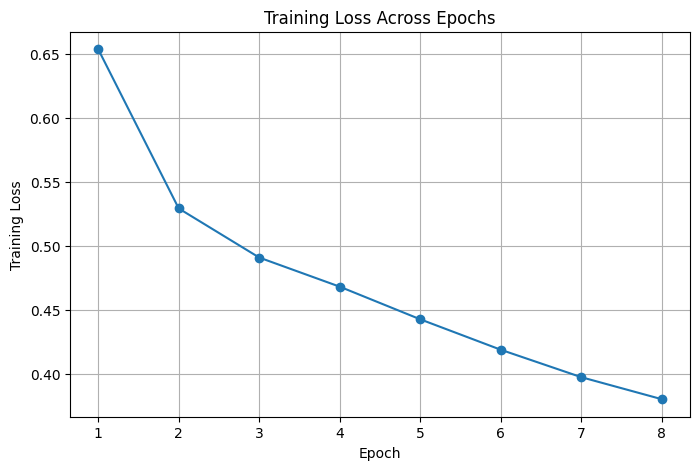

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Epochs")
plt.grid(True)
plt.savefig("../results/figures/reliable_subset_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

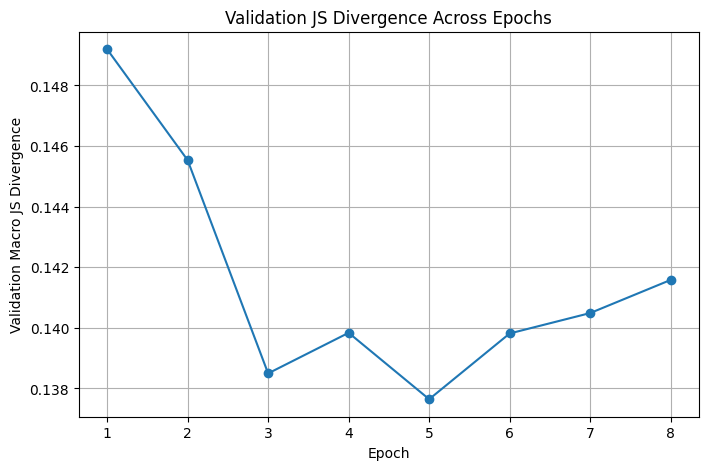

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_macro_js"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro JS Divergence")
plt.title("Validation JS Divergence Across Epochs")
plt.grid(True)
plt.savefig("../results/figures/reliable_subset_validation_js.png", dpi=300, bbox_inches="tight")
plt.show()

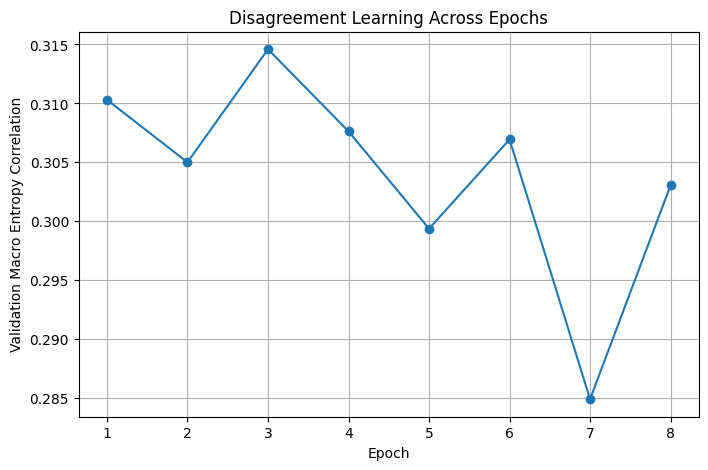

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_macro_entropy_correlation"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro Entropy Correlation")
plt.title("Disagreement Learning Across Epochs")
plt.grid(True)
plt.savefig("../results/figures/reliable_subset_entropy_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

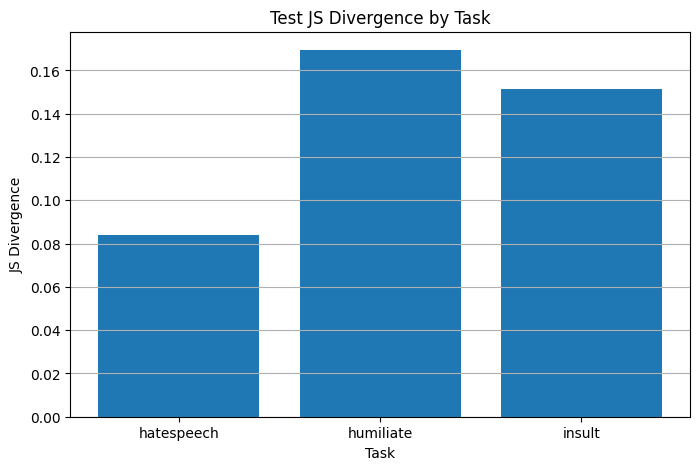

In [46]:
plot_df = test_metrics[test_metrics["task"] != "MACRO_AVERAGE"]

plt.figure(figsize=(8, 5))
plt.bar(plot_df["task"], plot_df["js_divergence"])
plt.xlabel("Task")
plt.ylabel("JS Divergence")
plt.title("Test JS Divergence by Task")
plt.grid(axis="y")
plt.savefig("../results/figures/test_js_by_task.png", dpi=300, bbox_inches="tight")
plt.show()

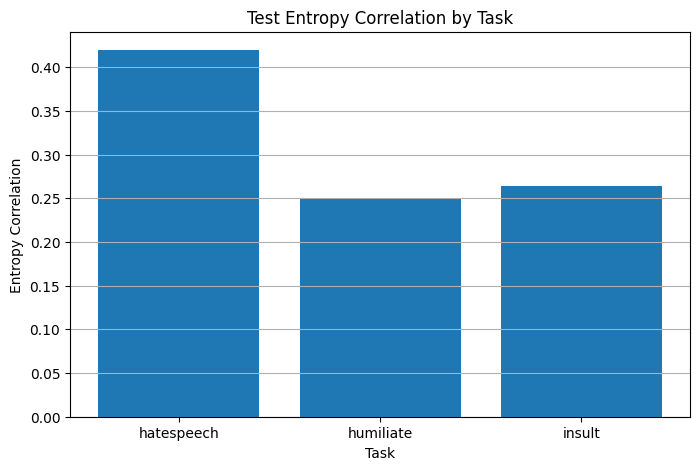

In [47]:
plt.figure(figsize=(8, 5))
plt.bar(plot_df["task"], plot_df["entropy_correlation"])
plt.xlabel("Task")
plt.ylabel("Entropy Correlation")
plt.title("Test Entropy Correlation by Task")
plt.grid(axis="y")
plt.savefig("../results/figures/test_entropy_corr_by_task.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
!pip install PyEvALL -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [49]:
import json
from torch.utils.data import DataLoader

In [50]:
def collect_predictions_for_pyevall(model, loader, original_df, split_name):
    model.eval()

    rows = []
    example_index = 0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            labels = {
                task: batch[f"{task}_labels"].float()
                for task in task_names
            }

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            )

            batch_size = batch["input_ids"].shape[0]

            for i in range(batch_size):
                comment_id = str(original_df.iloc[example_index]["comment_id"])

                for task, label_values in task_specs.items():
                    probs = torch.nn.functional.softmax(
                        outputs[task][i],
                        dim=-1
                    ).detach().cpu().numpy()

                    gold = labels[task][i].detach().cpu().numpy()

                    pred_value = {
                        str(label): float(probs[j])
                        for j, label in enumerate(label_values)
                    }

                    gold_value = {
                        str(label): float(gold[j])
                        for j, label in enumerate(label_values)
                    }

                    rows.append({
                        "split": split_name,
                        "task": task,
                        "id": comment_id,
                        "prediction": pred_value,
                        "gold": gold_value
                    })

                example_index += 1

    return rows

In [51]:
test_pyevall_rows = collect_predictions_for_pyevall(
    model=model,
    loader=test_loader,
    original_df=test_df,
    split_name="test"
)

len(test_pyevall_rows)

2115

In [52]:
pyevall_dir = "../results/pyevall/reliable_subset_multitask_lewidi_1"
os.makedirs(pyevall_dir, exist_ok=True)

pyevall_files = {}

for task in task_names:
    task_rows = [
        row for row in test_pyevall_rows
        if row["task"] == task
    ]

    gold_records = []
    pred_records = []

    for row in task_rows:
        record_id = row["id"]

        gold_records.append({
            "test_case": task,
            "id": record_id,
            "value": row["gold"]
        })

        pred_records.append({
            "test_case": task,
            "id": record_id,
            "value": row["prediction"]
        })

    gold_path = os.path.join(pyevall_dir, f"{task}_gold.json")
    pred_path = os.path.join(pyevall_dir, f"{task}_pred.json")

    with open(gold_path, "w", encoding="utf-8") as f:
        json.dump(gold_records, f, indent=2)

    with open(pred_path, "w", encoding="utf-8") as f:
        json.dump(pred_records, f, indent=2)

    pyevall_files[task] = {
        "gold": gold_path,
        "pred": pred_path
    }

pyevall_files

{'hatespeech': {'gold': '../results/pyevall/reliable_subset_multitask_lewidi_1/hatespeech_gold.json',
  'pred': '../results/pyevall/reliable_subset_multitask_lewidi_1/hatespeech_pred.json'},
 'humiliate': {'gold': '../results/pyevall/reliable_subset_multitask_lewidi_1/humiliate_gold.json',
  'pred': '../results/pyevall/reliable_subset_multitask_lewidi_1/humiliate_pred.json'},
 'insult': {'gold': '../results/pyevall/reliable_subset_multitask_lewidi_1/insult_gold.json',
  'pred': '../results/pyevall/reliable_subset_multitask_lewidi_1/insult_pred.json'}}

In [53]:
from pyevall.evaluation import PyEvALLEvaluation
from pyevall.utils.utils import PyEvALLUtils
from pyevall.metrics.metricfactory import MetricFactory

In [55]:
pyevall_results = {}

metrics = [
    "CrossEntropy",
    "ICMSoft",
    "ICMSoftNorm"
]

for task in task_names:
    pred_path = pyevall_files[task]["pred"]
    gold_path = pyevall_files[task]["gold"]

    params = {
        PyEvALLUtils.PARAM_REPORT: PyEvALLUtils.PARAM_OPTION_REPORT_EMBEDDED
    }

    evaluator = PyEvALLEvaluation()

    report = evaluator.evaluate(
        pred_path,
        gold_path,
        metrics,
        **params
    )

    pyevall_results[task] = report

pyevall_results

2026-05-27 08:25:24,682 - pyevall.evaluation - INFO -             evaluate() - Evaluating the following metrics ['CrossEntropy', 'ICMSoft', 'ICMSoftNorm']
2026-05-27 08:25:24,926 - pyevall.metrics.metrics - INFO -             evaluate() - Executing Cross Entropy evaluation method for testcase hatespeech
2026-05-27 08:25:25,380 - pyevall.metrics.metrics - INFO -             evaluate() - Executing ICM Soft evaluation method for testcase hatespeech
2026-05-27 08:25:26,402 - pyevall.metrics.metrics - INFO -             evaluate() - Executing ICM-Soft Normalized evaluation method for testcase hatespeech
2026-05-27 08:25:26,405 - pyevall.metrics.metrics - INFO -             evaluate() - Executing ICM Soft evaluation method for testcase hatespeech
2026-05-27 08:25:28,507 - pyevall.metrics.metrics - INFO -             evaluate() - Executing ICM Soft evaluation method for testcase hatespeech
cargado 46
2026-05-27 08:25:29,453 - pyevall.evaluation - INFO -             evaluate() - Evaluating the

{'hatespeech': <pyevall.reports.reports.PyEvALLEmbeddedReport at 0x7a70b819f6e0>,
 'humiliate': <pyevall.reports.reports.PyEvALLEmbeddedReport at 0x7a701016dd60>,
 'insult': <pyevall.reports.reports.PyEvALLEmbeddedReport at 0x7a70fb6e2d80>}

In [57]:
pyevall_report_path = "../results/tables/roberta_reliable_subset_multitask_lewidi_1_pyevall_results.txt"

with open(pyevall_report_path, "w", encoding="utf-8") as f:
    f.write("PYEVAL LEWIDI EVALUATION RESULTS\n")
    f.write("=" * 90 + "\n\n")

    for task, report in pyevall_results.items():
        f.write(f"TASK: {task}\n")
        f.write("-" * 90 + "\n")

        if hasattr(report, "report"):
            f.write(str(report.report))
        elif hasattr(report, "to_json"):
            f.write(str(report.to_json()))
        elif hasattr(report, "get_report"):
            f.write(str(report.get_report()))
        else:
            f.write(str(report.__dict__))

        f.write("\n\n")

print(open(pyevall_report_path, encoding="utf-8").read())

PYEVAL LEWIDI EVALUATION RESULTS

TASK: hatespeech
------------------------------------------------------------------------------------------
{'metrics': {'CrossEntropy': {'name': 'Cross Entropy', 'acronym': 'CE', 'description': 'Coming soon!', 'status': 'OK', 'results': {'test_cases': [{'name': 'hatespeech', 'average': 0.9937982145655381}], 'average_per_test_case': 0.9937982145655381}}, 'ICMSoft': {'name': 'Information Contrast Model Soft', 'acronym': 'ICM-Soft', 'description': 'Coming soon!', 'status': 'OK', 'results': {'test_cases': [{'name': 'hatespeech', 'average': -1.7761542103257832}], 'average_per_test_case': -1.7761542103257832}}, 'ICMSoftNorm': {'name': 'Normalized Information Contrast Model Soft', 'acronym': 'ICM-Soft-Norm', 'description': 'Coming soon!', 'status': 'OK', 'results': {'test_cases': [{'name': 'hatespeech', 'average': 0.3101857055104187}], 'average_per_test_case': 0.3101857055104187}}}, 'files': {'hatespeech_pred.json': {'name': 'hatespeech_pred.json', 'status':